In [12]:
import math
import matplotlib.pyplot as plt
from sympy import symbols, Eq, solve, I
import numpy as np 

#Start with silicon!

z = 1 #Little charge z of proton or something

Z = 14
A = 28
Na = 6.022e23 #Avogadro's number, there is an implicit g/cm^3 in here
re = 2.83e-13 #Classical radius of electron in cm
me = 0.511 #MeV/c^2
c = 2.9979e8

#Good approximation for I for Z > 1. 


In [17]:
4*3.14*Na*re**2*me

0.30954526257972803

Best fit a: 130.56125661331302
Best fit b: 0.20472585873851423
Best fit c: -0.0068897616550971305
[4.64939551e+07 7.29046407e+04 2.45355189e+03]


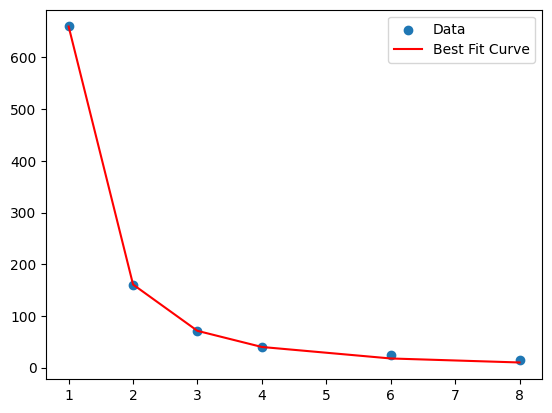

(array([ 3.24982633e+01,  5.07698349e-02, -1.52572871e-03]), array([[-5.11468927e+13, -7.99033267e+10,  2.40124453e+09],
       [-7.99033267e+10, -1.24827556e+08,  3.75130171e+06],
       [ 2.40124453e+09,  3.75130171e+06, -1.12733638e+05]]))


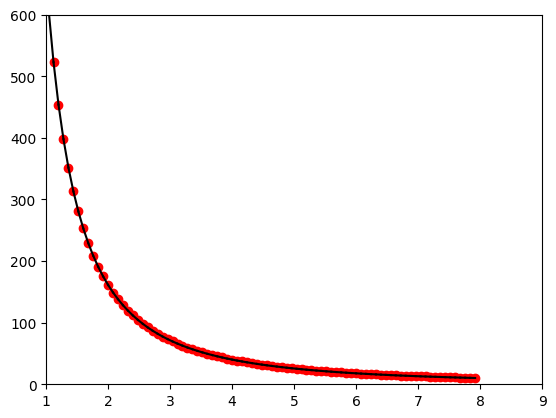

In [36]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

x = np.array([1, 2, 3, 4, 6, 8])
y = np.array([660, 160, 72, 42, 20, 10])


def fit_func(x, a, b, c):
    return a/(b*x**2 + c)


def connectpoints(x, y, p1, p2):
    x1, x2 = x[p1], x[p2]
    y1, y2 = y[p1], y[p2]
    plt.plot([x1, x2], [y1, y2], 'k-')


xmin = 1
xmax = 9
params = curve_fit(fit_func, x, y)
print(curve_fit(fit_func, x, y))

[a, b, c] = params[0]
y = []
numpoints = 100

for i in range(numpoints):
    y.append(a/(b*(i/numpoints*(xmax-xmin))**2+c))

x=[]
for i in range(numpoints):
    x.append(i/numpoints*(xmax-xmin))

plt.plot(x, y, 'ro')
for i in range(0,len(x)-1):
    if y[i] >0:
        connectpoints(x, y, i, i+1)

plt.xlim([xmin, xmax])
plt.ylim([0, 600])

plt.show()

Best fit a: 130.56125661331302
Best fit b: 0.20472585873851423
Best fit c: -0.0068897616550971305
Error? [4.64939551e+07 7.29046407e+04 2.45355189e+03]


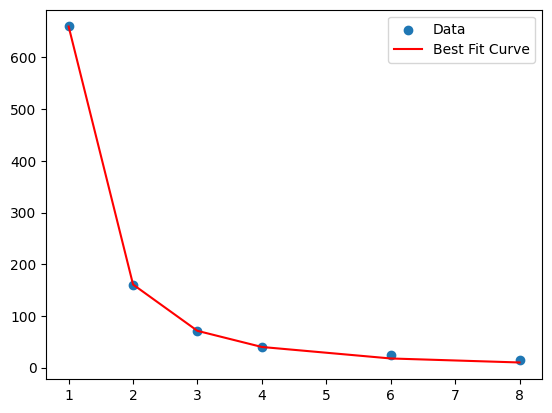

In [43]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# 1. Sample data (replace with your actual data)
xdata = np.array([1, 2, 3, 4, 6, 8])
ydata = np.array([660, 160, 70, 40, 25, 14])

# 2. Define the function to fit (e.g., a power law type function)
def func(x, a, b, c):
    return a / (b * x**2 + c)

# 3. Use curve_fit to find optimal parameters
# popt contains the optimal parameters (a, b, c)
# pcov is the covariance matrix
popt, pcov = curve_fit(func, xdata, ydata)

# 4. Extract parameters and plot
a_fit, b_fit, c_fit = popt

print("Best fit a: " + str(a_fit))
print("Best fit b: " + str(b_fit))
print("Best fit c: " + str(c_fit))

perr = np.sqrt(np.diag(np.abs(pcov)))
print(f'Error? {perr}')

plt.scatter(xdata, ydata, label='Data')
plt.plot(xdata, func(xdata, a_fit, b_fit, c_fit), 'r-', label='Best Fit Curve')
plt.legend()
plt.show()

Optimized parameters: a = 2.4976290619731176, b = 1.3023626434344653
Error: [0.02919289 0.00188543]


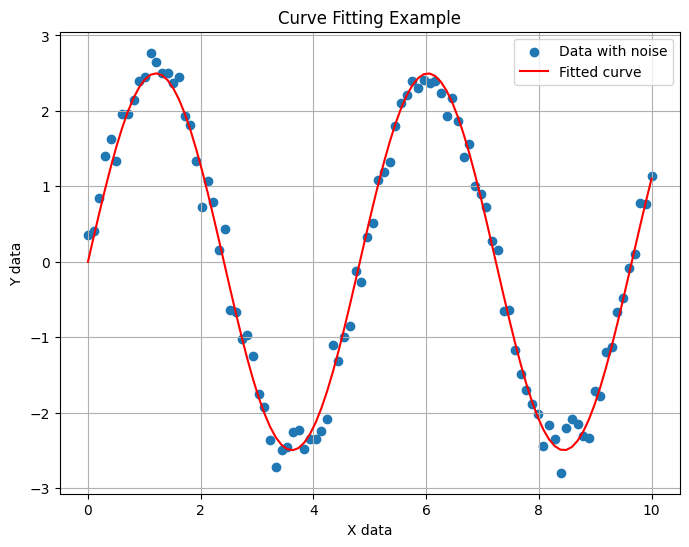

In [40]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def model_func(x, a, b):
    return a * np.sin(b * x)
np.random.seed(0)
xdata = np.linspace(0, 10, 100)
y = model_func(xdata, 2.5, 1.3)
ydata = y + 0.2 * np.random.normal(size=len(xdata))
plt.figure(figsize=(8, 6))
plt.scatter(xdata, ydata, label='Data with noise')

# Fitting the function to the data using curve_fit
popt, pcov = curve_fit(model_func, xdata, ydata)
# Getting the optimized parameters
a_opt, b_opt = popt
print(f'Optimized parameters: a = {a_opt}, b = {b_opt}')

perr = np.sqrt(np.diag(pcov))
print(f'Error: {perr}')

plt.plot(xdata, model_func(xdata, *popt), 'r-', label='Fitted curve')

plt.xlabel('X data')
plt.ylabel('Y data')
plt.title('Curve Fitting Example')
plt.legend()
plt.grid(True)
plt.show()

In [86]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

#Define a model function for the Bethe-Bloch. Let's just do Total E, so fold in rho and width here!!!
#def BB_func(x, a, b):
#    return a * np.sin(b * x)

Beta = [0.755,0.765,0.775,0.785,0.795,0.805,0.815,0.825,0.835,0.845,0.855,0.865,0.875,0.885,0.895,0.905,0.915,0.925,0.935,0.945,0.955,0.965,0.975,0.985,0.995]
EdepTKR = [1.23283,1.18031,1.09367,1.03836,0.971921,0.93095,0.926406,0.913445,0.873909,0.807427,0.760887,0.817,0.859633,0.852098,0.856863,0.861688,0.87575,0.860655,0.846012,0.823805,0.832255,0.810291,0.834349,0.802206,0.828727]
EdepTOF = [2.37357,2.23402,2.05184,1.97207,1.966,1.94495,1.8698,1.7386,1.65333,1.61914,1.64359,1.62607,1.53248,1.47271,1.50651,1.55089,1.51795,1.51934,1.54024,1.52712,1.5248,1.5331,1.53973,1.49933,1.50859]

Text(0.5, 1.0, 'Mean Edep TKR')

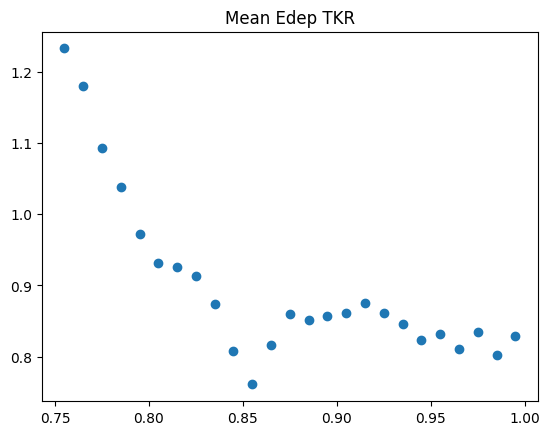

In [89]:
plt.scatter(Beta, EdepTKR, label='Tracker Data')
plt.title("Mean Edep TKR")

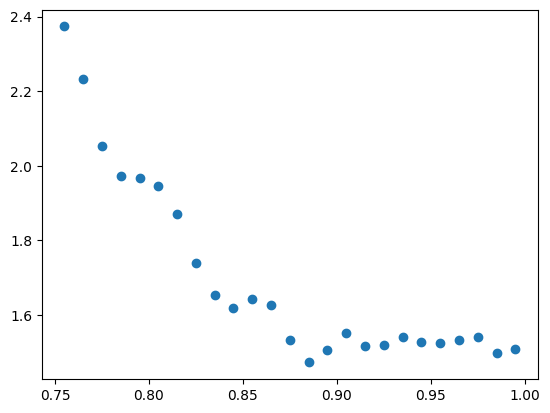

In [79]:
plt.scatter(Beta, EdepTOF, label='Data')

m is 105.658
[1.29004417 1.29727745 1.30471077 1.31237073 1.3202875  1.32849554
 1.33703453 1.34595055 1.35529755 1.36513939 1.37555249 1.38662938
 1.39848378 1.4112576  1.42513128 1.4403393  1.45719421 1.47612603
 1.49774972 1.52298969 1.55333045 1.59138719 1.64246019 1.72024608
 1.88822814]


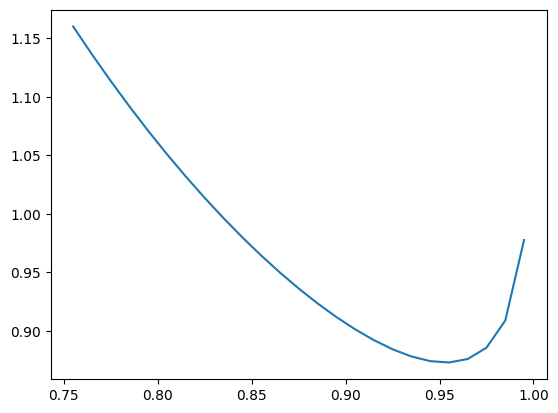

In [148]:
import math
import matplotlib.pyplot as plt
from sympy import symbols, Eq, solve, I
import numpy as np 

ylow = 1
yhigh = 30

#Let's do muons in silicon
z = 1 #protons or muons
Zeff = 14 #5.575 #Si 14
Aeff = 28 #10.3 #Si 28
rho = 2.33 #1.032 #Density g/cm^2
L = 0.22 #0.635 #Length of material region in cm
dx = 0.01
#dx = 0.0005 #When you're ready for a final calculation, dx = 0.0005 is adequately small #This is the step size in the array which gets you from 0 to the length of the thing you're in.
x = np.arange(0, L, dx)
b = symbols('b')
#m = 938.3 #proton mass #105.658 #Muon mass
m = 105.658
print("m is " + str(m))

#beta = [0.05,0.1,0.2,0.4,0.6,0.8, 0.9,0.99,0.999,0.9999,0.99999]
#beta = [0.7,0.75,0.8,0.85,0.87,0.9,0.93,0.95,0.97,0.99]
beta = [0.755,0.765,0.775,0.785,0.795,0.805,0.815,0.825,0.835,0.845,0.855,0.865,0.875,0.885,0.895,0.905,0.915,0.925,0.935,0.945,0.955,0.965,0.975,0.985,0.995]
gamma = [1/math.sqrt(1 - x**2) for x in beta]
lterm = np.zeros(len(beta))
dE = np.zeros(len(beta))
dEbetasq = np.zeros(len(beta))
gbet = np.zeros(len(beta))
coeff = np.zeros(len(beta))

for i in range(len(beta)):
    delta = 2*math.log(gamma[i])
    dE[i] = (rho*L)*0.3071*z**2*(Zeff/Aeff)*(1/beta[i]**2)*(math.log(1.022 * gamma[i]**2 * beta[i]**2 / (16 * Zeff**0.9 * 10**-6) ) - beta[i]**2)
    dEbetasq[i] = 0.3071*z**2*(Zeff/Aeff)*(math.log(1.022 * gamma[i]**2 * beta[i]**2 / (16 * Zeff**0.9 * 10**-6) ) - beta[i]**2)
    coeff[i] = beta[i]/np.sqrt(math.log(1.022 * gamma[i]**2 * beta[i]**2 / (16 * Zeff**0.9 * 10**-6) ) - beta[i]**2)
    gbet[i] = gamma[i]*beta[i]
    lterm[i] = math.log(1.022 * gamma[i]**2 * beta[i]**2 / (16 * Zeff**0.9 * 10**-6)) - beta[i]**2
    #print("Log term = " + str(lterm[i])) 
    #print("(1/Beta^2) * Log term = " + str((1/beta[i]**2) * lterm[i])) 
    #print("gbet = " + str(gbet[i]))
    #print("delta = " + str(delta))
    #print("dEbetasq = " + str(dEbetasq[i]))
    #print("coeff = " + str(coeff[i]))
    #print("dE no delta = " + str(dE[i]))
    #print()

print(dEbetasq)
plt.plot(beta,dE)

[0.92787614 1.        ]


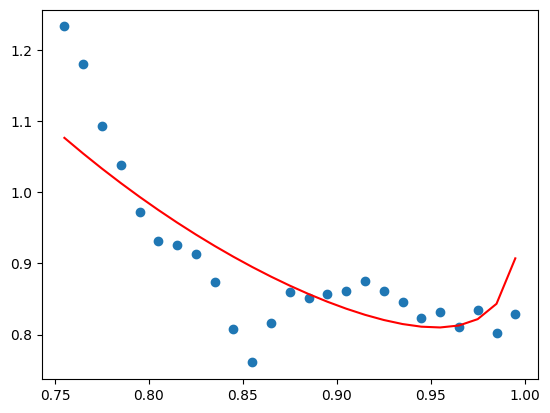

In [196]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

Beta = np.array([0.755,0.765,0.775,0.785,0.795,0.805,0.815,0.825,0.835,0.845,0.855,0.865,0.875,0.885,0.895,0.905,0.915,0.925,0.935,0.945,0.955,0.965,0.975,0.985,0.995])
EdepTKR = np.array([1.23283,1.18031,1.09367,1.03836,0.971921,0.93095,0.926406,0.913445,0.873909,0.807427,0.760887,0.817,0.859633,0.852098,0.856863,0.861688,0.87575,0.860655,0.846012,0.823805,0.832255,0.810291,0.834349,0.802206,0.828727])
EdepTOF = np.array([2.37357,2.23402,2.05184,1.97207,1.966,1.94495,1.8698,1.7386,1.65333,1.61914,1.64359,1.62607,1.53248,1.47271,1.50651,1.55089,1.51795,1.51934,1.54024,1.52712,1.5248,1.5331,1.53973,1.49933,1.50859])

#Let's do muons in silicon
z = 1 #protons or muons
Zeff = 14 #TOF 5.575 #Si 14
Aeff = 28 #TOF 10.3 #Si 28
rho = 2.33 #TOF 1.032 #Si 2.33 #Density g/cm^2
L = 0.22 #TOF 0.635 #Length of material region in cm
dx = 0.01
#dx = 0.0005 #When you're ready for a final calculation, dx = 0.0005 is adequately small #This is the step size in the array which gets you from 0 to the length of the thing you're in.
x = np.arange(0, L, dx)
b = symbols('b')
a = 1
B = 1
#m = 938.3 #proton mass #105.658 #Muon mass
m = 105.658

#Define a model function for the Bethe-Bloch. Let's just do Total E, so fold in rho and width here!!!
def BB_func(x, a, B):
    #return a*0.3071*z**2*(Zeff/Aeff)*(1/x**2)* (math.log( b*1.022*x**2 / (np.sqrt(1-x**2)*16 * Zeff**0.9 * 10**-6) ) - x**2)
    return (rho*L)*a*0.3071*(1/x**2)*(Zeff/Aeff)*z**2 * (np.log( 1.022 * x**2 / ((1-x**2)*16 *Zeff**0.9 * 10**-6) ) - x**2)
    
#(math.log( b*1.022*x**2 / (np.sqrt(1-x**2)*16 * 15**0.9 * 10**-6) ) - x**2)
    
popt, pcov = curve_fit(BB_func, Beta, EdepTKR)
print(popt)

plt.scatter(Beta, EdepTKR, label='Tracker Data')
plt.plot(Beta, BB_func(Beta, *popt), 'r-', label='Fitted curve')
#plt.plot(Beta, BB_func(Beta, *[1.016,1]), 'r-', label='Fitted curve')

#plt.title("Mean Edep TKR")

[1.16460067 1.        ]


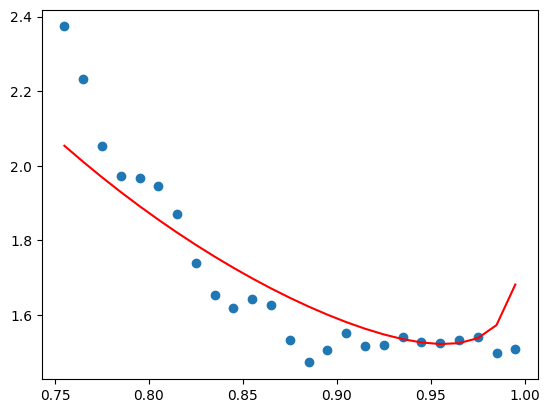

In [194]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

Beta = np.array([0.755,0.765,0.775,0.785,0.795,0.805,0.815,0.825,0.835,0.845,0.855,0.865,0.875,0.885,0.895,0.905,0.915,0.925,0.935,0.945,0.955,0.965,0.975,0.985,0.995])
EdepTKR = np.array([1.23283,1.18031,1.09367,1.03836,0.971921,0.93095,0.926406,0.913445,0.873909,0.807427,0.760887,0.817,0.859633,0.852098,0.856863,0.861688,0.87575,0.860655,0.846012,0.823805,0.832255,0.810291,0.834349,0.802206,0.828727])
EdepTOF = np.array([2.37357,2.23402,2.05184,1.97207,1.966,1.94495,1.8698,1.7386,1.65333,1.61914,1.64359,1.62607,1.53248,1.47271,1.50651,1.55089,1.51795,1.51934,1.54024,1.52712,1.5248,1.5331,1.53973,1.49933,1.50859])

#Let's do muons in silicon
z = 1 #protons or muons
Zeff = 5.574 #TOF 5.575 #Si 14
Aeff = 10.3 #TOF 10.3 #Si 28
rho = 1.032 #TOF 1.032 #Si 2.33 #Density g/cm^2
L = 0.635 #TOF 0.635 #Length of material region in cm
dx = 0.01
#dx = 0.0005 #When you're ready for a final calculation, dx = 0.0005 is adequately small #This is the step size in the array which gets you from 0 to the length of the thing you're in.
#x = np.arange(0, L, dx)
b = symbols('b')
a = 1
B = 1
#m = 938.3 #proton mass #105.658 #Muon mass
m = 105.658

#Define a model function for the Bethe-Bloch. Let's just do Total E, so fold in rho and width here!!!
def BB_func(Beta, a, B):
    #return (rho*L)*a*0.3071*(1/Beta**2)*(Zeff/Aeff)*z**2 * (np.log( 1.022*Beta**2 / ( np.sqrt(1-Beta**2) *16 * Zeff**0.9 * B * 10**-6) ) - Beta**2)
    return (rho*L)*a*0.3071*(1/Beta**2)*(Zeff/Aeff)*z**2 * (np.log( 1.022*Beta**2 / ( (1-Beta**2) *16 * Zeff**0.9 * 10**-6) ) - Beta**2)
    
#(math.log( b*1.022*x**2 / (np.sqrt(1-x**2)*16 * 15**0.9 * 10**-6) ) - x**2)
    
popt, pcov = curve_fit(BB_func, Beta, EdepTOF)
print(popt)

plt.scatter(Beta, EdepTOF, label='Tracker Data')
plt.plot(Beta, BB_func(Beta, *popt), 'r-', label='Fitted curve')
#plt.plot(Beta, BB_func(Beta, *[0.7,5]), 'r-', label='Fitted curve')

#plt.title("Mean Edep TKR")

In [184]:
(rho*L)*a*0.3071*(1/Beta**2)*(Zeff/Aeff)*z**2 * (np.log( 1.022*Beta**2 / ( (1-Beta**2) *16 * Zeff**0.9 * 10**-6) ) - Beta**2)

array([57.31199267, 56.10832885, 54.95498143, 53.85029612, 52.79281866,
       51.78130107, 50.81471275, 49.89225765, 49.01339941, 48.17789733,
       47.38585714, 46.63780285, 45.93477928, 45.27850047, 44.67156932,
       44.11781133, 43.6227996 , 43.1947163 , 42.84584392, 42.59532758,
       42.4747685 , 42.54102215, 42.91124534, 43.89237256, 46.9255675 ])

In [218]:
Beta = np.array([0.755,0.765,0.775,0.785,0.795,0.805,0.815,0.825,0.835,0.845,0.855,0.865,0.875,0.885,0.895,0.905,0.915,0.925,0.935,0.945,0.955,0.965,0.975,0.985,0.995])
EdepTKR = np.array([1.23283,1.18031,1.09367,1.03836,0.971921,0.93095,0.926406,0.913445,0.873909,0.807427,0.760887,0.817,0.859633,0.852098,0.856863,0.861688,0.87575,0.860655,0.846012,0.823805,0.832255,0.810291,0.834349,0.802206,0.828727])
EdepTOF = np.array([2.37357,2.23402,2.05184,1.97207,1.966,1.94495,1.8698,1.7386,1.65333,1.61914,1.64359,1.62607,1.53248,1.47271,1.50651,1.55089,1.51795,1.51934,1.54024,1.52712,1.5248,1.5331,1.53973,1.49933,1.50859])

Zeff_tof = 5.574 #TOF 5.575 #Si 14
Aeff_tof = 10.3 #TOF 10.3 #Si 28
rho_tof = 1.032 #TOF 1.032 #Si 2.33 #Density g/cm^2
L_tof = 0.635 #TOF 0.635 #Length of material region in cm

Zeff_tkr = 14 #TOF 5.575 #Si 14
Aeff_tkr = 28.3 #TOF 10.3 #Si 28
rho_tkr = 2.33 #TOF 1.032 #Si 2.33 #Density g/cm^2
L_tkr = 0.22 #TOF 0.635 #Length of material region in cm

#dx = 0.01
#dx = 0.0005 #When you're ready for a final calculation, dx = 0.0005 is adequately small #This is the step size in the array which gets you from 0 to the length of the thing you're in.
#x = np.arange(0, L, dx)
b = symbols('b')
a = 1
B = 1
Gtof = (1/1.1646)
Gtkr = (1/0.928)

z_calc_tof = np.zeros(len(beta))
z_calc_tkr = np.zeros(len(beta))

for i in range(len(Beta)):
    print((Aeff_tof/Zeff_tof) * EdepTOF[i] * (1/(rho_tof*L_tof)) * (1/0.307) * Beta[i]**2)
    print((np.log( 1.022*(Beta[i]**2 / (1 - Beta[i]**2)) / (16*(10**-6) * Zeff_tof**0.9 ) ) - Beta[i]**2))
    z_calc_tof[i] = np.sqrt(Gtof *( (Aeff_tof/Zeff_tof) * EdepTOF[i] * (1/(rho_tof*L_tof)) * (1/0.307) * Beta[i]**2) / (np.log( 1.022*(Beta[i]**2 / (1 - Beta[i]**2)) / (16*(10**-6) * Zeff_tof**0.9 ) ) - Beta[i]**2))
    z_calc_tkr[i] = np.sqrt(Gtkr *( (Aeff_tkr/Zeff_tkr) * EdepTKR[i] * (1/(rho_tkr*L_tkr)) * (1/0.307) * Beta[i]**2) / (np.log( 1.022*(Beta[i]**2 / (1 - Beta[i]**2)) / (16*(10**-6) * Zeff_tkr**0.9 ) ) - Beta[i]**2))
print(z_calc_tof)
print(z_calc_tkr)


12.427232103682767
9.230309843405582
12.008489685620106
9.27741687549374
11.319450881558536
9.325826645944982
11.16195075719312
9.375712404575639
11.4129058100267
9.427270640600101
11.576536999290449
9.480725816858623
11.407456863463972
9.536336346056673
10.868911052682005
9.594402224081481
10.587927513858762
9.655274906664685
10.618820561841904
9.719370272672698
11.035809166677316
9.787185911763634
11.17506131326046
9.859324594699638
10.776789095195335
9.936526788360641
10.594543279612665
10.019716753122724
11.084000882886784
10.110069660227886
11.66693065025385
10.209112399590735
11.672882580385247
10.318880663798206
11.940345664805292
10.442174806118881
12.36773245594097
10.58299987457008
12.526081821744492
10.747376105054693
12.77315224810856
10.9449714101239
13.113045634624541
11.192817308237421
13.444116440984077
11.525432131144495
13.361282735516271
12.032015579472903
13.71815950875182
13.126004923911351
[1.07520351 1.05424674 1.02089392 1.01106603 1.01956927 1.02395329
 1.01348